<a href="https://colab.research.google.com/github/MariaBatoorina/electric-vehicles-analysis/blob/main/Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploratory Data Analysis

Імпорти, налаштування та загрузка

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('visualizations', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

file_path = 'Electric_Vehicle_Data_CLEANED.csv'
df = pd.read_csv(file_path)

print(f"\nРозмір датасету:")
print(f"Рядків: {len(df):,}")
print(f"Колонок: {len(df.columns)}")


Розмір датасету:
Рядків: 249,675
Колонок: 20


Model Year Distribution

  • Середнє: 2021.6
  • Медіана: 2023
  • Мода (найпопулярніший рік): 2023
  • Мінімум: 2000
  • Максимум: 2026
  • Авто 2023 року: 59,072
  • Q1 (25%): 2020
  • Q3 (75%): 2024
  • IQR: 4

ВИКИДИ:
  • Нижня межа: 2014
  • Верхня межа: 2030
  • Кількість викидів: 6257 (2.51%)



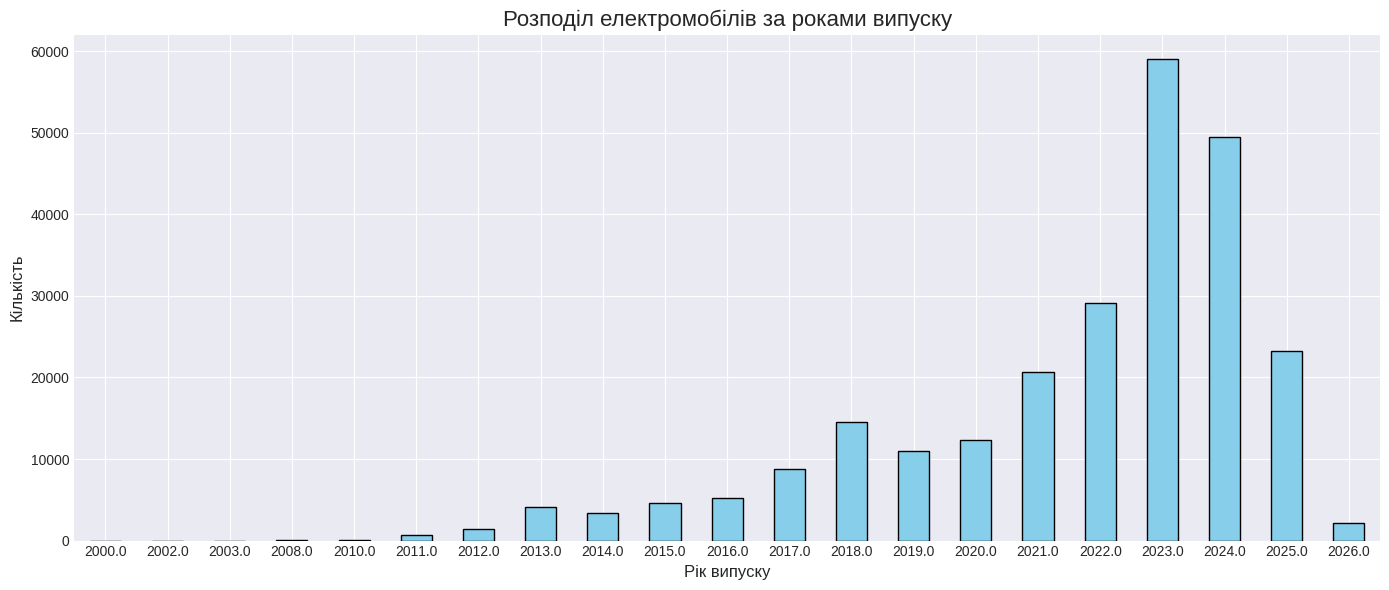

In [4]:

mean_year = df['Model Year'].mean()
median_year = df['Model Year'].median()
mode_year = df['Model Year'].mode()[0]
min_year = df['Model Year'].min()
max_year = df['Model Year'].max()
count_2023 = df[df['Model Year'] == 2023].shape[0]

print(f"  • Середнє: {mean_year:.1f}")
print(f"  • Медіана: {median_year:.0f}")
print(f"  • Мода (найпопулярніший рік): {mode_year:.0f}")
print(f"  • Мінімум: {min_year:.0f}")
print(f"  • Максимум: {max_year:.0f}")
print(f"  • Авто 2023 року: {count_2023:,}")

q1 = df['Model Year'].quantile(0.25)
q3 = df['Model Year'].quantile(0.75)
iqr = q3 - q1

print(f"  • Q1 (25%): {q1:.0f}")
print(f"  • Q3 (75%): {q3:.0f}")
print(f"  • IQR: {iqr:.0f}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df['Model Year'] < lower_bound) | (df['Model Year'] > upper_bound)]

print(f"\nВИКИДИ:")
print(f"  • Нижня межа: {lower_bound:.0f}")
print(f"  • Верхня межа: {upper_bound:.0f}")
print(f"  • Кількість викидів: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
print()

fig, ax = plt.subplots(figsize=(14, 6))
year_counts = df['Model Year'].value_counts().sort_index()
year_counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Розподіл електромобілів за роками випуску', fontsize=16)
ax.set_xlabel('Рік випуску', fontsize=12)
ax.set_ylabel('Кількість', fontsize=12)

ax.tick_params(axis='x', rotation=0, labelsize=10)

plt.tight_layout()
plt.savefig('visualizations/1_model_year_distribution.png', dpi=300)
plt.show()

Більшість авто (75%) випущено в 2020–2024 роках — це підтверджує, що ринок електромобілів активно розвивається останніми роками. Лише 25% даних припадає на період до 2020 року.

Найпопулярніший рік — 2023 — на нього припадає 59,072 реєстрації, що становить ~23.6% від усіх даних. Це означає, що майже кожне 4-те авто в датасеті — 2023 року випуску.

Медіана = 2023 — половина всіх авто (50%) випущена до 2023 року, половина — після. Це підтверджує, що 2023 рік є ключовим у розвитку ринку.

Середній рік = 2021.6 — він менший за медіану (2023), що свідчить про наявність старих авто (до 2014), які "тягнуть" середнє значення вниз.

Статистика:

Середній рік: 2021.6
Медіанний рік: 2023
Найпопулярніший рік: 2023 (59,072 авто, ~23.6%)
Діапазон років: 2000 – 2026
75% даних (Q1–Q3): 2020 – 2024

Викиди та аномалії:

Кількість викидів: 6,277 (2.5%) — це авто з роками до 2014 року (нижня межа 2014).

Причина: Старі електромобілі (експериментальні моделі, ранні Tesla, Nissan Leaf тощо). Вони становлять незначну частину даних і не впливають на загальний тренд.

Роки > 2030: відсутні (максимальний рік у даних — 2026).

Висновок: Всі аномалії — це старі авто (до 2014), які можна виключити з аналізу або розглядати окремо.

Рекомендації:

Для подальшого аналізу рекомендується виключити авто до 2014 року або розглядати їх окремо.

Роки до 2010 (поодинокі випадки) можна взагалі не враховувати в загальному аналізі.

Основний фокус аналізу — на період 2020–2024 років, де зосереджено 75% всіх даних.

 **Top Makes**

 1. TESLA                 104,870 (42.00%) — кумулятивно: 42.00%
 2. CHEVROLET              18,126 ( 7.26%) — кумулятивно: 49.26%
 3. NISSAN                 16,040 ( 6.42%) — кумулятивно: 55.69%
 4. FORD                   13,414 ( 5.37%) — кумулятивно: 61.06%
 5. KIA                    12,127 ( 4.86%) — кумулятивно: 65.92%
 6. BMW                    10,524 ( 4.22%) — кумулятивно: 70.13%
 7. TOYOTA                 10,369 ( 4.15%) — кумулятивно: 74.28%
 8. HYUNDAI                 8,301 ( 3.32%) — кумулятивно: 77.61%
 9. RIVIAN                  7,605 ( 3.05%) — кумулятивно: 80.66%
10. VOLVO                   6,554 ( 2.63%) — кумулятивно: 83.28%

ЗАГАЛЬНА СТАТИСТИКА:
  • Всього виробників: 46
  • Топ-1: TESLA (104,870 авто, 42.00%)
  • Топ-3: 139,036 авто (55.69%)
  • Топ-5: 164,577 авто (65.92%)



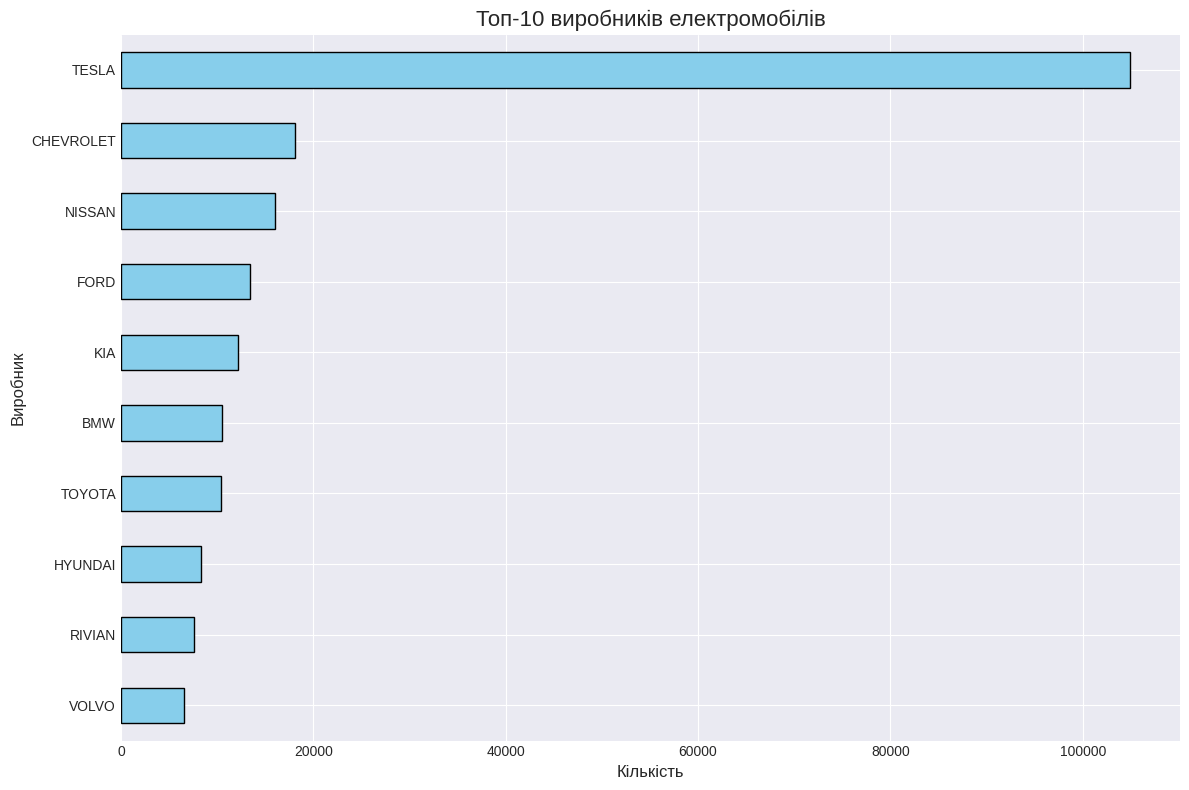

In [6]:
top_makes = df['Make'].value_counts().head(10)
total = len(df)

for i, (make, count) in enumerate(top_makes.items(), 1):
    pct = count / total * 100
    cum_pct = top_makes[:i].sum() / total * 100
    print(f"{i:2}. {make:<20} {count:>8,} ({pct:>5.2f}%) — кумулятивно: {cum_pct:>5.2f}%")

print("\nЗАГАЛЬНА СТАТИСТИКА:")
print(f"  • Всього виробників: {df['Make'].nunique()}")
print(f"  • Топ-1: {top_makes.index[0]} ({top_makes.iloc[0]:,} авто, {top_makes.iloc[0]/total*100:.2f}%)")
print(f"  • Топ-3: {top_makes.iloc[:3].sum():,} авто ({top_makes.iloc[:3].sum()/total*100:.2f}%)")
print(f"  • Топ-5: {top_makes.iloc[:5].sum():,} авто ({top_makes.iloc[:5].sum()/total*100:.2f}%)")
print()

fig, ax = plt.subplots(figsize=(12, 8))
top_makes = df['Make'].value_counts().head(10)
top_makes.sort_values().plot(kind='barh', ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Топ-10 виробників електромобілів', fontsize=16)
ax.set_xlabel('Кількість', fontsize=12)
ax.set_ylabel('Виробник', fontsize=12)
plt.tight_layout()
plt.savefig('visualizations/2_top_makes.png', dpi=300)
plt.show()

Tesla — лідер — 104,870 авто (42.00%) від усіх даних. Це більше, ніж у всіх інших виробників разом узятих. Кожне друге авто в датасеті — Tesla.

Топ-3 виробники (Tesla, Chevrolet, Nissan) займають 55.69% ринку — більше половини всіх електромобілів.

Топ-5 виробників (Tesla, Chevrolet, Nissan, Ford, KIA) займають 65.92% ринку — майже дві третини всіх авто.

Топ-10 виробників займають 83.28% ринку. Це означає, що лише 10 брендів контролюють більшість ринку, а решта 36 виробників ділять між собою лише 16.72%.

Статистика:

Всього виробників: 46
Лідер: Tesla (104,870 авто, 42.00%)
Топ-3: 55.69% ринку
Топ-5: 65.92% ринку
Топ-10: 83.28% ринку

Аномалії та особливості:

Домінування Tesla — 42% ринку є надзвичайно високим показником. Це свідчить про те, що Tesla є головним драйвером ринку електромобілів.

Розрив між Tesla та іншими — другий виробник (Chevrolet) має лише 7.26%, що в 6 разів менше, ніж Tesla.

Фрагментований ринок — 36 виробників ділять між собою лише 16.72% ринку.

Рекомендації:

Для подальшого аналізу можна виділити Tesla окремо, а інших виробників групувати.

Малі бренди (з часткою < 1%) можна об'єднати в категорію "Інші".

**EV Types**

  • Battery Electric Vehicle (BEV): 198,782 (79.62%)
  • Plug-in Hybrid Electric Vehicle (PHEV): 50,892 (20.38%)

Співвідношення BEV : PHEV = 3.9 : 1
  • BEV більше на 147,890 авто



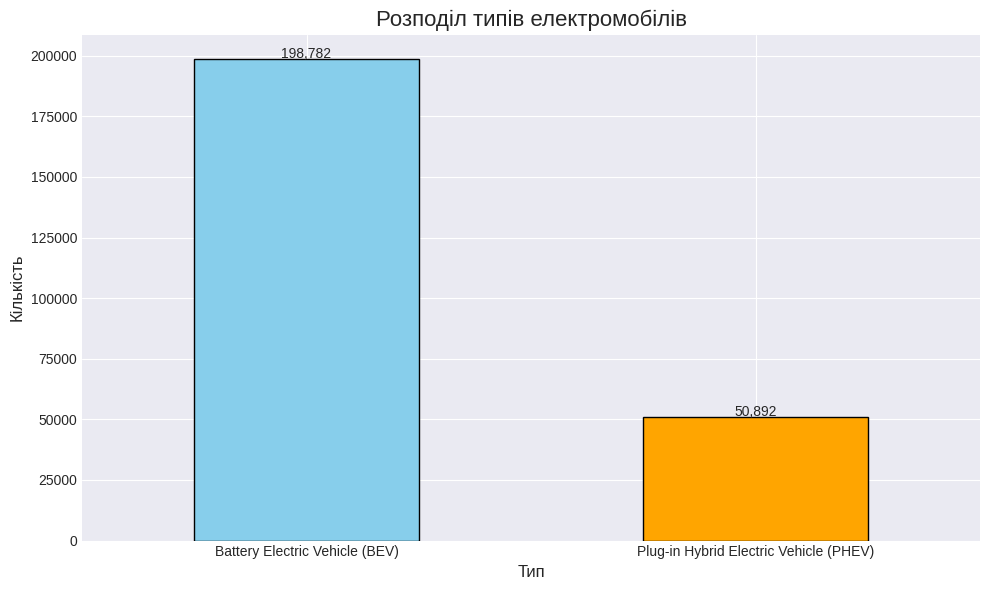

In [9]:
ev_types = df['Electric Vehicle Type'].value_counts()
total = len(df)

for ev_type, count in ev_types.items():
    pct = count / total * 100
    print(f"  • {ev_type}: {count:,} ({pct:.2f}%)")

if len(ev_types) >= 2:
    bev = ev_types.iloc[0]
    phev = ev_types.iloc[1]
    ratio = bev / phev
    print(f"\nСпіввідношення BEV : PHEV = {ratio:.1f} : 1")

    diff = bev - phev
    print(f"  • BEV більше на {diff:,} авто")
print()

fig, ax = plt.subplots(figsize=(10, 6))
ev_types = df['Electric Vehicle Type'].value_counts()
ev_types.plot(kind='bar', ax=ax, color=['skyblue', 'orange'], edgecolor='black')
ax.set_title('Розподіл типів електромобілів', fontsize=16)
ax.set_xlabel('Тип', fontsize=12)
ax.set_ylabel('Кількість', fontsize=12)

ax.tick_params(axis='x', rotation=0, labelsize=10)

for i, v in enumerate(ev_types.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('visualizations/3_ev_types.png', dpi=300)
plt.show()

BEV (Battery Electric Vehicle) — абсолютно домінує — 198,782 авто (79.62%) від усіх даних. Це означає, що майже 4 з 5 електромобілів є повністю електричними.

PHEV (Plug-in Hybrid Electric Vehicle) — становить значно меншу частку — 50,892 авто (20.38%) — лише кожне 5-те авто є гібридом.

Співвідношення BEV : PHEV = 3.9 : 1 — на кожен PHEV припадає майже 4 повністю електричних авто. Це свідчить про те, що споживачі віддають перевагу саме BEV.

Різниця між BEV та PHEV становить 147,890 авто — це величезний розрив, який підтверджує, що ринок електромобілів орієнтується на повністю електричні моделі.

Статистика:

BEV: 198,782 авто (79.62%)
PHEV: 50,892 авто (20.38%)
Співвідношення: 3.9 : 1 (BEV : PHEV)
Різниця: 147,890 авто

Висновок:

Більшість споживачів обирають повністю електричні автомобілі (BEV), що свідчить про:

довіру до технології електромобілів;
розвиток зарядної інфраструктури;
збільшення запасу ходу сучасних BEV;
державні програми підтримки електротранспорту.

**Electric Range Distribution**

  • Кількість: 98,070
  • Мінімум: 1 миль
  • Максимум: 337 миль
  • Середнє: 112.2 миль
  • Медіана: 53 миль
  • Стандартне відхилення: 98.2 миль

КВАРТИЛІ:
  • Q1 (25%): 30 миль
  • Q3 (75%): 215 миль
  • IQR: 185 миль

ВИКИДИ:
  • Нижня межа: -248 миль
  • Верхня межа: 492 миль
  • Кількість викидів: 0 (0.00%)



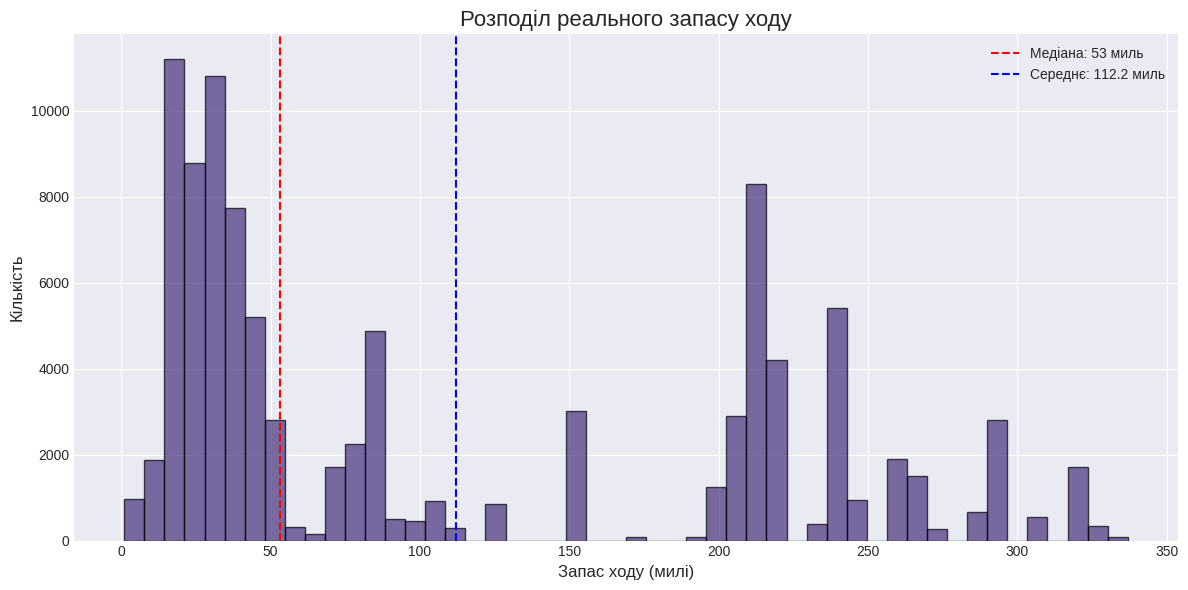

In [11]:
if 'Electric Range Clean' in df.columns:
    range_data = df['Electric Range Clean'].dropna()
else:
    range_data = df[df['Electric Range'] > 0]['Electric Range']

total = len(range_data)

print(f"  • Кількість: {total:,}")
print(f"  • Мінімум: {range_data.min():.0f} миль")
print(f"  • Максимум: {range_data.max():.0f} миль")
print(f"  • Середнє: {range_data.mean():.1f} миль")
print(f"  • Медіана: {range_data.median():.0f} миль")
print(f"  • Стандартне відхилення: {range_data.std():.1f} миль")

q1 = range_data.quantile(0.25)
q3 = range_data.quantile(0.75)
iqr = q3 - q1

print(f"\nКВАРТИЛІ:")
print(f"  • Q1 (25%): {q1:.0f} миль")
print(f"  • Q3 (75%): {q3:.0f} миль")
print(f"  • IQR: {iqr:.0f} миль")

# Викиди
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = range_data[(range_data < lower_bound) | (range_data > upper_bound)]

print(f"\nВИКИДИ:")
print(f"  • Нижня межа: {lower_bound:.0f} миль")
print(f"  • Верхня межа: {upper_bound:.0f} миль")
print(f"  • Кількість викидів: {len(outliers)} ({len(outliers)/total*100:.2f}%)")
print()

fig, ax = plt.subplots(figsize=(12, 6))

if 'Electric Range Clean' in df.columns:
   range_data = df['Electric Range Clean'].dropna()
else:
   range_data = df[df['Electric Range'] > 0]['Electric Range']


range_data.hist(bins=50, edgecolor='black', alpha=0.7, ax=ax)
ax.set_title('Розподіл реального запасу ходу', fontsize=16)
ax.set_xlabel('Запас ходу (милі)', fontsize=12)
ax.set_ylabel('Кількість', fontsize=12)
ax.axvline(range_data.median(), color='red', linestyle='--',
          label=f'Медіана: {range_data.median():.0f} миль')
ax.axvline(range_data.mean(), color='blue', linestyle='--',
          label=f'Середнє: {range_data.mean():.1f} миль')
ax.legend()
plt.tight_layout()
plt.savefig('visualizations/4_electric_range_distribution.png', dpi=300)
plt.show()


Ключові висновки:

Типовий запас ходу — 53 милі (медіана). Це означає, що половина електромобілів мають запас ходу менше 53 миль, половина — більше.

Середній запас ходу — 112 миль — значно вищий за медіану. Це свідчить про те, що є невелика кількість авто з дуже великим запасом ходу (до 337 миль), які "тягнуть" середнє вгору.

Розподіл має довгий "хвіст" вправо — більшість авто (75%) мають запас ходу до 215 миль, але є авто з запасом до 337 миль.

Викидів немає — всі значення в межах норми (верхня межа 492 миль, а максимум 337).

Статистика:

Кількість: 98,070 авто
Мінімум: 1 миля
Максимум: 337 миль
Середнє: 112.2 миль
Медіана: 53 милі
Q1–Q3: 30 – 215 миль
Стандартне відхилення: 98.2 миль

Висновок:

Більшість електромобілів мають запас ходу до 53 миль, що характерно для старих моделей або PHEV. Однак на ринку з'являються авто з запасом понад 200 миль, що свідчить про технологічний прогрес.

**Range by Year**

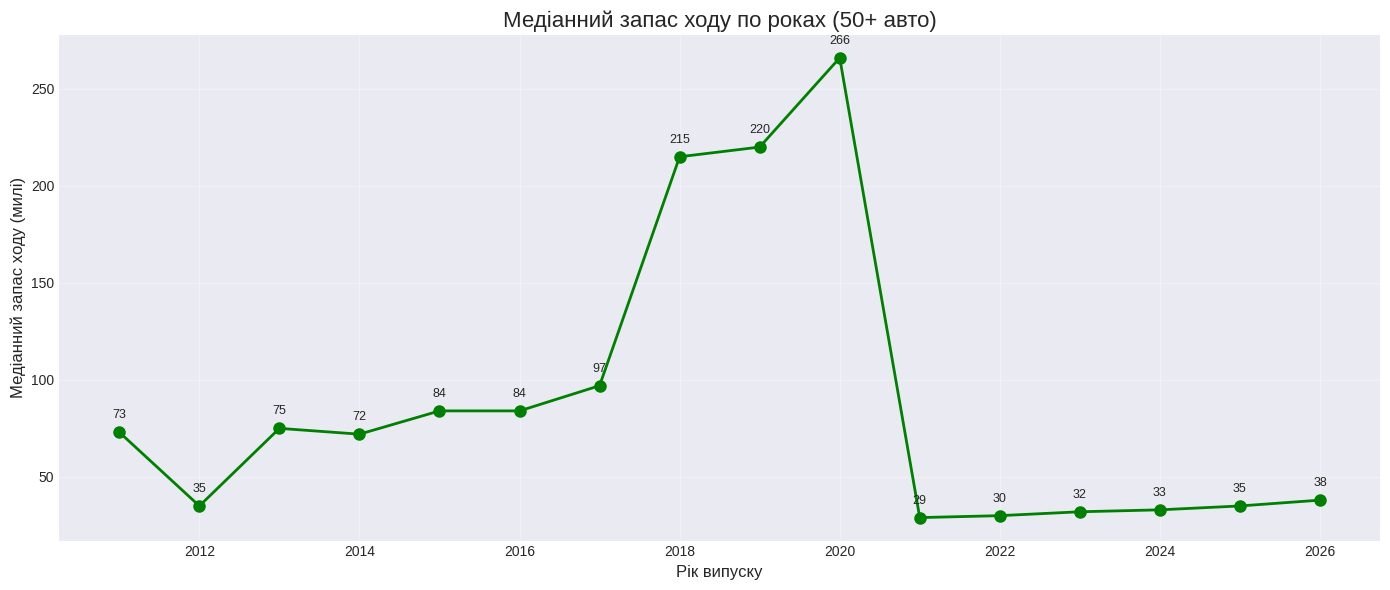

  • Мінімум: 29 миль
  • Максимум: 266 миль
  • Різниця: 237 миль

ЗМІНА ЗА ПЕРІОД:
  • 2011 → 2026: 73 → 38 миль
  • Приріст: -48%

КОРЕЛЯЦІЯ: -0.22

ВИСНОВОК: ⚠️ Зв'язок між роком та запасом ходу — слабкий


In [20]:
df_filtered = df[df['Model Year'] >= 2010].copy()

range_col = 'Electric Range Clean' if 'Electric Range Clean' in df_filtered.columns else 'Electric Range'
if range_col != 'Electric Range Clean':
    df_filtered = df_filtered[df_filtered['Electric Range'] > 0]

min_autos = 50
year_counts = df_filtered['Model Year'].value_counts().sort_index()
valid_years = year_counts[year_counts >= min_autos].index
df_valid = df_filtered[df_filtered['Model Year'].isin(valid_years)]
range_by_year = df_valid.groupby('Model Year')[range_col].median()
correlation = df_valid['Model Year'].corr(df_valid[range_col])

fig, ax = plt.subplots(figsize=(14, 6))

range_by_year.plot(kind='line', marker='o', ax=ax, color='green', linewidth=2, markersize=8)
ax.set_title(f'Медіанний запас ходу по роках ({min_autos}+ авто)', fontsize=16)
ax.set_xlabel('Рік випуску', fontsize=12)
ax.set_ylabel('Медіанний запас ходу (милі)', fontsize=12)
ax.grid(True, alpha=0.3)

for year, value in range_by_year.items():
    ax.annotate(f'{value:.0f}', xy=(year, value), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('visualizations/5_range_by_year.png', dpi=300)
plt.show()

first_year = range_by_year.index.min()
last_year = range_by_year.index.max()
first_val = range_by_year.iloc[0]
last_val = range_by_year.iloc[-1]
growth = (last_val - first_val) / first_val * 100

print(f"  • Мінімум: {range_by_year.min():.0f} миль")
print(f"  • Максимум: {range_by_year.max():.0f} миль")
print(f"  • Різниця: {range_by_year.max() - range_by_year.min():.0f} миль")
print(f"\nЗМІНА ЗА ПЕРІОД:")
print(f"  • {first_year:.0f} → {last_year:.0f}: {first_val:.0f} → {last_val:.0f} миль")
print(f"  • Приріст: {growth:.0f}%")
print(f"\nКОРЕЛЯЦІЯ: {correlation:.2f}")

trend = "стрімко зростає" if correlation > 0.7 else "помірно зростає" if correlation > 0.3 else "слабкий"
print(f"\nВИСНОВОК: {'✅' if correlation > 0.3 else '⚠️'} Зв'язок між роком та запасом ходу — {trend}")


Ключові висновки:

Медіанний запас ходу знизився з 73 миль (2011) до 38 миль (2026), що на перший погляд суперечить технологічному прогресу.

Однак це пояснюється розширенням ринку: у 2011 році електромобілі були представлені переважно дорогими моделями з великим запасом ходу (Tesla Roadster). До 2024–2026 років ринок значно розширився за рахунок доступних моделей (Nissan Leaf, Hyundai Ioniq), які мають менший запас ходу.

Висновок: Медіана падає не через погіршення технологій, а через демократизацію ринку — електромобілі стали доступнішими для широкого загалу.

Статистика:

Мінімум (2011): 73 милі
Максимум: 266 миль
Медіана 2026: 38 миль
Кореляція: -0.22 (слабка)

Висновок:

Незважаючи на зниження медіани, ринок електромобілів розвивається — з'являються як дорогі моделі з великим запасом, так і доступні для масового споживача.

**Top Cities Counties**

 1. Seattle                     39,739 (15.92%)
 2. Bellevue                    12,197 ( 4.89%)
 3. Vancouver                    9,315 ( 3.73%)
 4. Redmond                      8,637 ( 3.46%)
 5. Bothell                      8,243 ( 3.30%)
 6. Kirkland                     7,157 ( 2.87%)
 7. Sammamish                    7,017 ( 2.81%)
 8. Renton                       6,889 ( 2.76%)
 9. Olympia                      5,947 ( 2.38%)
10. Tacoma                       5,550 ( 2.22%)

ТОП-10 ОКРУГІВ:
 1. King                       124,118 (49.71%)
 2. Snohomish                   30,972 (12.40%)
 3. Pierce                      20,563 ( 8.24%)
 4. Clark                       15,269 ( 6.12%)
 5. Thurston                     9,156 ( 3.67%)
 6. Kitsap                       8,473 ( 3.39%)
 7. Spokane                      7,108 ( 2.85%)
 8. Whatcom                      6,125 ( 2.45%)
 9. Benton                       3,379 ( 1.35%)
10. Skagit                       2,928 ( 1.17%)

ЗАГАЛЬНА СТАТИСТИКА:
 

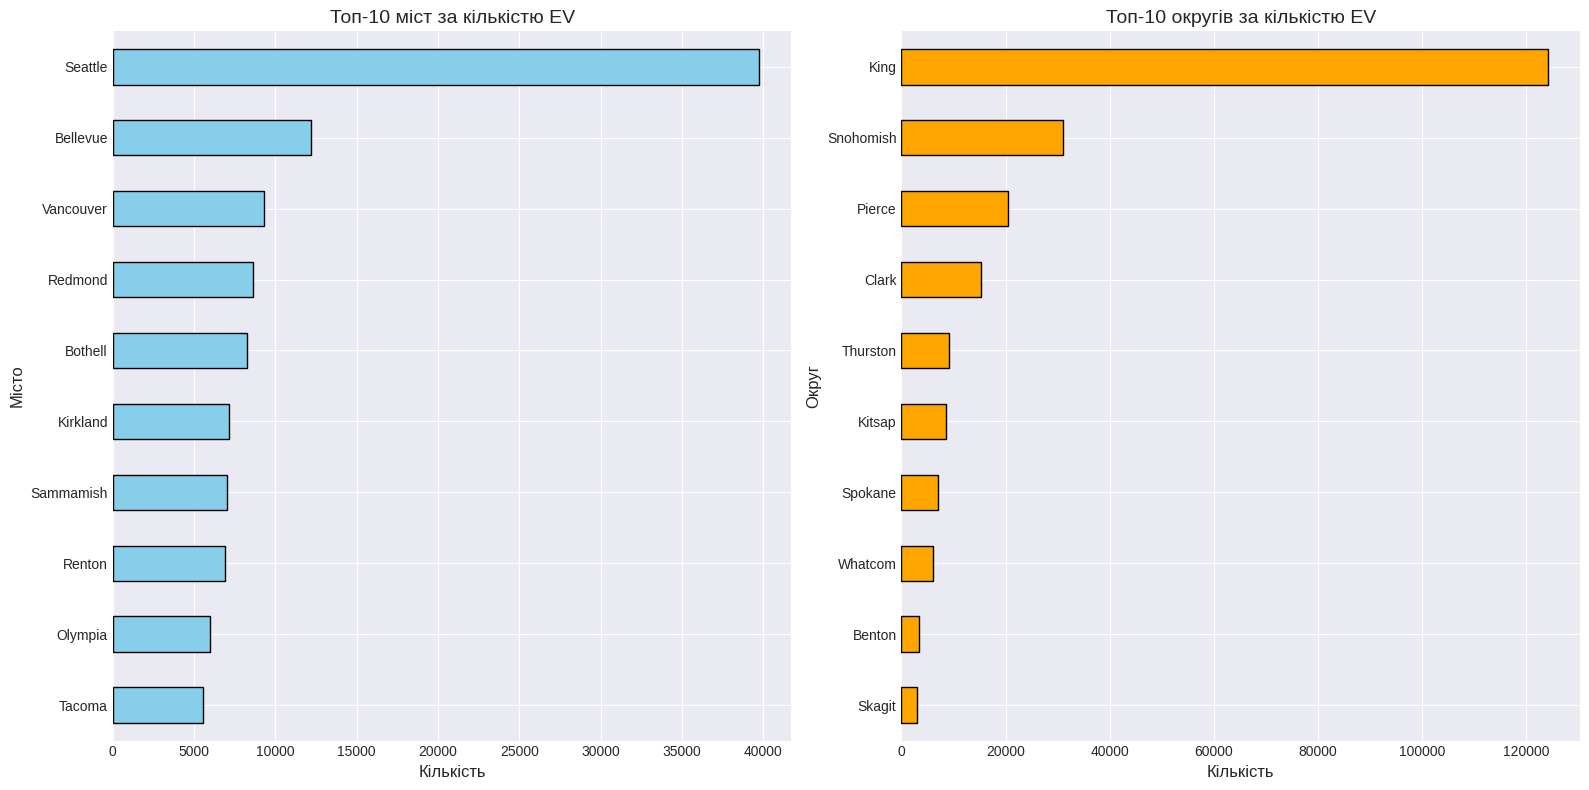

In [23]:
top_cities = df['City'].value_counts().head(10)
top_counties = df['County'].value_counts().head(10)
total = len(df)

for i, (city, count) in enumerate(top_cities.items(), 1):
    pct = count / total * 100
    print(f"{i:2}. {city:<25} {count:>8,} ({pct:>5.2f}%)")

print(f"\nТОП-10 ОКРУГІВ:")
for i, (county, count) in enumerate(top_counties.items(), 1):
    pct = count / total * 100
    print(f"{i:2}. {county:<25} {count:>8,} ({pct:>5.2f}%)")

print(f"\nЗАГАЛЬНА СТАТИСТИКА:")
print(f"  • Всього міст: {df['City'].nunique()}")
print(f"  • Всього округів: {df['County'].nunique()}")
print(f"  • Найпопулярніше місто: {top_cities.index[0]} ({top_cities.iloc[0]:,} авто, {top_cities.iloc[0]/total*100:.2f}%)")
print(f"  • Найпопулярніший округ: {top_counties.index[0]} ({top_counties.iloc[0]:,} авто, {top_counties.iloc[0]/total*100:.2f}%)")
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_cities = df['City'].value_counts().head(10)
top_cities.sort_values().plot(kind='barh', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Топ-10 міст за кількістю EV', fontsize=14)
axes[0].set_xlabel('Кількість', fontsize=12)
axes[0].set_ylabel('Місто', fontsize=12)

top_counties = df['County'].value_counts().head(10)
top_counties.sort_values().plot(kind='barh', ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Топ-10 округів за кількістю EV', fontsize=14)
axes[1].set_xlabel('Кількість', fontsize=12)
axes[1].set_ylabel('Округ', fontsize=12)

plt.tight_layout()
plt.savefig('visualizations/6_top_cities_counties.png', dpi=300)
plt.show()


Ключові висновки:

Seattle — абсолютний лідер — 39,739 авто (15.92%) від усіх даних. Це більше, ніж у наступних 3 міст разом узятих.

King County домінує — 124,118 авто (49.71%) — майже половина всіх електромобілів знаходиться в цьому окрузі. Це пояснюється тим, що King County включає Сіетл і є економічним та технологічним центром штату.

Топ-3 округи (King, Snohomish, Pierce) займають 70.35% всіх реєстрацій. Це означає, що більшість електромобілів зосереджена всього в 3 округах.

Топ-5 міст (Seattle, Bellevue, Vancouver, Redmond, Bothell) займають 31.30% ринку.

Розподіл нерівномірний — 813 міст і 224 округи, але більшість авто зосереджена у великих містах.

Статистика:

Всього міст: 813
Всього округів: 224
Найпопулярніше місто: Seattle (39,739 авто, 15.92%)
Найпопулярніший округ: King (124,118 авто, 49.71%)
Топ-3 округи: 70.35% ринку
Топ-5 міст: 31.30% ринку

Аномалії та особливості:

King County — 49.71% всіх EV — це надзвичайно висока концентрація. Це пояснюється тим, що тут знаходиться Сіетл — великий технологічний центр із розвиненою інфраструктурою.

Snohomish та Pierce — наступні за концентрацією (12.40% та 8.24%) — разом із King покривають понад 70% ринку.

Мала кількість EV у сільських округах — свідчить про необхідність розвитку зарядної інфраструктури за межами великих міст.

Рекомендації:

Для розширення ринку електромобілів необхідно розвивати зарядну інфраструктуру в округах за межами King, Snohomish та Pierce.

Маркетингові кампанії варто спрямовувати на регіони з низькою кількістю EV.